In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [47]:
df = pd.read_csv('D:\mca_aiml_lab\mca_env\Datasets\BHARTIARTL.csv')

df.head()

<>:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\HP\AppData\Local\Temp\ipykernel_14412\2929416509.py:1: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  df = pd.read_csv('D:\mca_aiml_lab\mca_env\Datasets\BHARTIARTL.csv')


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2002-02-18,BHARTI,EQ,0.00,51.90,51.90,43.50,44.70,44.35,46.00,10381190,4.775431e+13,NaN,6503775.0,0.6265
1,2002-02-19,BHARTI,EQ,44.35,45.15,45.15,41.30,41.35,41.70,42.58,3552660,1.512609e+13,NaN,1741184.0,0.4901
2,2002-02-20,BHARTI,EQ,41.70,40.60,42.80,40.25,41.20,41.25,41.56,2512964,1.044348e+13,NaN,NaN,NaN
3,2002-02-21,BHARTI,EQ,41.25,42.85,43.40,42.15,42.20,42.40,42.76,1338196,5.722681e+12,NaN,485969.0,0.3632
4,2002-02-22,BHARTI,EQ,42.40,42.65,43.60,41.10,43.35,43.30,42.75,811327,3.468413e+12,NaN,399133.0,0.4920


In [48]:
df.shape

(4774, 15)

In [49]:
# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df = df.ffill()

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

df.reset_index(drop=True, inplace=True)

In [50]:
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2002-02-18,BHARTI,EQ,0.00,51.90,51.90,43.50,44.70,44.35,46.00,10381190,4.775431e+13,NaN,6503775.0,0.6265
1,2002-02-19,BHARTI,EQ,44.35,45.15,45.15,41.30,41.35,41.70,42.58,3552660,1.512609e+13,NaN,1741184.0,0.4901
2,2002-02-20,BHARTI,EQ,41.70,40.60,42.80,40.25,41.20,41.25,41.56,2512964,1.044348e+13,NaN,1741184.0,0.4901
3,2002-02-21,BHARTI,EQ,41.25,42.85,43.40,42.15,42.20,42.40,42.76,1338196,5.722681e+12,NaN,485969.0,0.3632
4,2002-02-22,BHARTI,EQ,42.40,42.65,43.60,41.10,43.35,43.30,42.75,811327,3.468413e+12,NaN,399133.0,0.4920


In [51]:
df['Trades'] = df['Turnover'] / (df['Close'] * 100)

df['Trades'] = df['Trades'].astype(int)



In [52]:
features = [
    'Prev Close', 'Open', 'High', 'Low', 'Last', 'Close',
    'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume'
]

data = df[features].values

In [53]:
data.shape

(4774, 11)

In [54]:
data

array([[0.00000000e+00, 5.19000000e+01, 5.19000000e+01, ...,
        4.77543140e+13, 1.07676018e+10, 6.50377500e+06],
       [4.43500000e+01, 4.51500000e+01, 4.51500000e+01, ...,
        1.51260941e+13, 3.62736070e+09, 1.74118400e+06],
       [4.17000000e+01, 4.06000000e+01, 4.28000000e+01, ...,
        1.04434783e+13, 2.53175231e+09, 1.74118400e+06],
       ...,
       [5.34300000e+02, 5.35950000e+02, 5.48000000e+02, ...,
        6.49786611e+14, 1.19380234e+10, 4.34424300e+06],
       [5.44300000e+02, 5.49700000e+02, 5.50000000e+02, ...,
        4.71369357e+14, 8.71534358e+09, 3.13838400e+06],
       [5.40850000e+02, 5.33500000e+02, 5.47000000e+02, ...,
        4.42388862e+14, 8.24199090e+09, 3.04510800e+06]], shape=(4774, 11))

In [55]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

In [56]:
data_scaled

array([[-1.83233449, -1.58158773, -1.58071106, ..., -0.44037901,
         0.67862029,  0.96076103],
       [-1.61830623, -1.61407835, -1.6125484 , ..., -0.52166537,
        -0.2147989 , -0.22664646],
       [-1.63109484, -1.63597943, -1.62363251, ..., -0.53333113,
        -0.35188636, -0.22664646],
       ...,
       [ 0.74613905,  0.7483506 ,  0.75921558, ...,  1.05945817,
         0.82506871,  0.42234728],
       [ 0.79439796,  0.8145352 ,  0.76864887, ...,  0.61496901,
         0.42183248,  0.12170295],
       [ 0.77774863,  0.73655771,  0.75449894, ...,  0.54277018,
         0.36260445,  0.09844741]], shape=(4774, 11))

### Create Time-Series Sequences

Examples :

- input : last 10 days
- output : next 5 days



In [57]:
def create_sequences(data, input_days=10, output_days=5):
    X, y = [], []
    for i in range(len(data) - input_days - output_days):
        X.append(data[i:i+input_days])
        y.append(data[i+input_days:i+input_days+output_days])  
    return np.array(X), np.array(y)

X , Y = create_sequences(data_scaled,10,5)

print(X.shape, Y.shape)

(4759, 10, 11) (4759, 5, 11)


#### Train-Test Split

In [58]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

### Convert to pytorch Tensors

In [59]:
X_train = torch.tensor(X_train, dtype=torch.float32)
Y_train = torch.tensor(Y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
Y_test = torch.tensor(Y_test, dtype=torch.float32)

#### Dataset and DataLoader

In [60]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]
    
train_loader = DataLoader(TimeSeriesDataset(X_train, Y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TimeSeriesDataset(X_test, Y_test), batch_size=32)

train_loader.dataset.X.shape, train_loader.dataset.Y.shape

(torch.Size([3807, 10, 11]), torch.Size([3807, 5, 11]))

In [61]:
train_loader.dataset.X

tensor([[[-1.8323, -1.5816, -1.5807,  ..., -0.4404,  0.6786,  0.9608],
         [-1.6183, -1.6141, -1.6125,  ..., -0.5217, -0.2148, -0.2266],
         [-1.6311, -1.6360, -1.6236,  ..., -0.5333, -0.3519, -0.2266],
         ...,
         [-1.6219, -1.6199, -1.6071,  ..., -0.5227, -0.2559, -0.3174],
         [-1.6169, -1.6100, -1.6048,  ..., -0.5103, -0.0746, -0.2660],
         [-1.6321, -1.6292, -1.6208,  ..., -0.5494, -0.5506, -0.5427]],

        [[-1.6183, -1.6141, -1.6125,  ..., -0.5217, -0.2148, -0.2266],
         [-1.6311, -1.6360, -1.6236,  ..., -0.5333, -0.3519, -0.2266],
         [-1.6333, -1.6251, -1.6208,  ..., -0.5451, -0.4998, -0.5396],
         ...,
         [-1.6169, -1.6100, -1.6048,  ..., -0.5103, -0.0746, -0.2660],
         [-1.6321, -1.6292, -1.6208,  ..., -0.5494, -0.5506, -0.5427],
         [-1.6272, -1.6239, -1.6168,  ..., -0.5527, -0.5916, -0.5744]],

        [[-1.6311, -1.6360, -1.6236,  ..., -0.5333, -0.3519, -0.2266],
         [-1.6333, -1.6251, -1.6208,  ..., -0

#### LSTM Model (Multi-Output)

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=11, hidden_size=64, output_size=5, num_layers=2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        #                     Or
        #self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size*input_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        lstm_out = lstm_out[:, -1, :]  # last time step
        out = self.fc(lstm_out)

        out = out.view(-1, 5, 11)  # reshape to (batch_size, output_days, features)
        return out

In [63]:
## Initialize Model, Loss, Optimizer

model = LSTMModel()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)



In [64]:
# Training Loop

num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    loss_total = 0

    for X_batch, Y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, Y_batch)
        loss.backward()
        optimizer.step()
        loss_total += loss.item()

    print(f'Epoch {epoch+1}, Loss: {loss_total:.4f}')

Epoch 1, Loss: 24.6024
Epoch 2, Loss: 9.2477
Epoch 3, Loss: 8.9752
Epoch 4, Loss: 8.8229
Epoch 5, Loss: 8.6852
Epoch 6, Loss: 8.6378
Epoch 7, Loss: 8.5266
Epoch 8, Loss: 8.5312
Epoch 9, Loss: 8.4645
Epoch 10, Loss: 8.3954
Epoch 11, Loss: 8.3611
Epoch 12, Loss: 8.3709
Epoch 13, Loss: 8.3065
Epoch 14, Loss: 8.2639
Epoch 15, Loss: 8.2187
Epoch 16, Loss: 8.2031
Epoch 17, Loss: 8.1307
Epoch 18, Loss: 8.0123
Epoch 19, Loss: 7.9610
Epoch 20, Loss: 7.8689
Epoch 21, Loss: 7.8776
Epoch 22, Loss: 7.7646
Epoch 23, Loss: 7.6146
Epoch 24, Loss: 7.5528
Epoch 25, Loss: 7.5072
Epoch 26, Loss: 7.5107
Epoch 27, Loss: 7.4097
Epoch 28, Loss: 7.3453
Epoch 29, Loss: 7.3231
Epoch 30, Loss: 7.3478
Epoch 31, Loss: 7.3391
Epoch 32, Loss: 7.2473
Epoch 33, Loss: 7.1516
Epoch 34, Loss: 7.3482
Epoch 35, Loss: 7.0815
Epoch 36, Loss: 7.0262
Epoch 37, Loss: 7.0583
Epoch 38, Loss: 7.0481
Epoch 39, Loss: 6.9532
Epoch 40, Loss: 6.8873
Epoch 41, Loss: 6.8788
Epoch 42, Loss: 6.8240
Epoch 43, Loss: 6.8329
Epoch 44, Loss: 6.7

In [65]:
# Evaluation Metrics 

model.eval()

predictions = []
actuals = []

with torch.no_grad():
    for X_batch, Y_batch in test_loader:
        outputs = model(X_batch)
        predictions.append(outputs.numpy())
        actuals.append(Y_batch.numpy())

    predictions = np.vstack(predictions)
    actuals = np.vstack(actuals)

    # Flatten for metric calculation
    pred_flat = predictions.reshape(-1, 11)
    actual_flat = actuals.reshape(-1, 11)

    mse = mean_squared_error(actual_flat, pred_flat)
    rmse = np.sqrt(mse) 
    mae = mean_absolute_error(actual_flat, pred_flat)

    print(f'MSE: {mse:.4f}, \nRMSE: {rmse:.4f}, \nMAE: {mae:.4f}')

MSE: 1.5349, 
RMSE: 1.2389, 
MAE: 0.5477


### Plot Predictions vs Actual

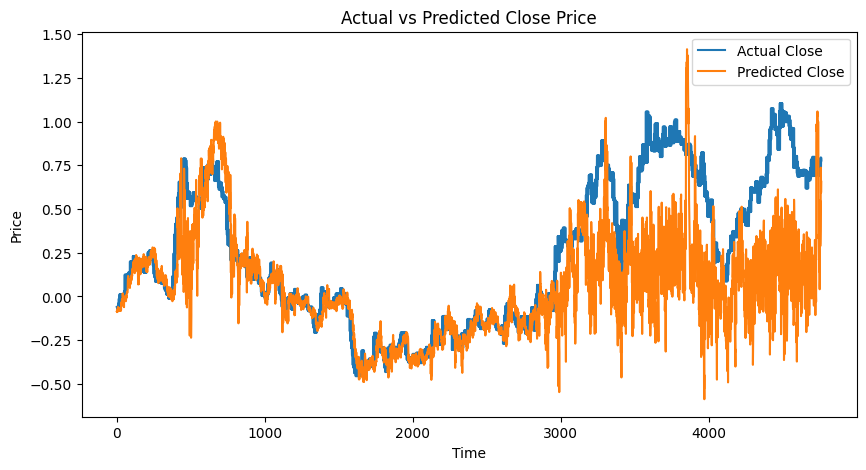

In [66]:
# Example : Plot Close Price

plt.figure(figsize=(10,5))

plt.plot(actual_flat[:, 5], label='Actual Close')
plt.plot(pred_flat[:, 5], label='Predicted Close')

plt.legend()
plt.title('Actual vs Predicted Close Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.show()